# ECG InceptionTime (Model B) - Training on Colab

**Instructions:**
1. Upload `ptbxl_sota_100hz_diagnostic_superclass.npz` to your Google Drive root
2. Runtime -> Change runtime type -> GPU (T4)
3. Run All cells

Expected time: ~15-25 min for 50 epochs on T4 GPU

In [1]:
# Cell 1: Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Cell 2: Check GPU
import torch
print(f'PyTorch: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

PyTorch: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4
Memory: 15.6 GB


In [3]:
# Cell 3: Copy data from Drive to Colab local storage (faster IO)
import shutil
from pathlib import Path

DRIVE_PATH = '/content/drive/MyDrive/ecg-diploma/data_preprocessed/ptbxl_sota_100hz_diagnostic_superclass.npz'
LOCAL_PATH = '/content/data.npz'

if not Path(LOCAL_PATH).exists():
    print('Copying data from Drive to local...')
    shutil.copy2(DRIVE_PATH, LOCAL_PATH)
    print(f'Done: {Path(LOCAL_PATH).stat().st_size / 1e9:.2f} GB')
else:
    print('Data already copied')

Copying data from Drive to local...
Done: 0.97 GB


In [4]:
# Cell 4: Verify data
import numpy as np

data = np.load(LOCAL_PATH, allow_pickle=True)
print('Keys:', list(data.keys()))
for k in data.keys():
    arr = data[k]
    if hasattr(arr, 'shape'):
        print(f'  {k}: shape={arr.shape}, dtype={arr.dtype}')
    else:
        print(f'  {k}: {arr}')

Keys: ['signals', 'labels', 'splits', 'ecg_ids', 'class_names', 'sampling_rate']
  signals: shape=(21799, 12, 1000), dtype=float32
  labels: shape=(21799, 5), dtype=float64
  splits: shape=(21799,), dtype=<U5
  ecg_ids: shape=(21799,), dtype=int64
  class_names: shape=(5,), dtype=<U4
  sampling_rate: shape=(), dtype=int64


In [5]:
# Cell 5: Dataset & DataLoader (same as Model A)
import random
import os
import warnings
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler


def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ['PYTHONHASHSEED'] = str(seed)
    print(f'Seed set: {seed}')


class ECGAugmentation:
    @staticmethod
    def add_gaussian_noise(signal, std=0.02):
        return signal + torch.randn_like(signal) * std

    @staticmethod
    def scale_amplitude(signal, scale_range=(0.85, 1.15)):
        scale = torch.empty(1).uniform_(*scale_range).item()
        return signal * scale

    @staticmethod
    def time_shift(signal, max_shift=50):
        shift = torch.randint(-max_shift, max_shift + 1, (1,)).item()
        return torch.roll(signal, shifts=shift, dims=-1)


class RandomApplyList:
    def __init__(self, transforms, p=0.5):
        self.transforms = transforms
        self.p = p
    def __call__(self, signal):
        for t in self.transforms:
            if random.random() < self.p:
                signal = t(signal)
        return signal


class PTBXLDataset(Dataset):
    def __init__(self, data_path, split='train', augment=False, seed=42):
        data = np.load(data_path, allow_pickle=True)

        all_signals = data['signals'].astype(np.float32)
        all_labels = data['labels'].astype(np.float32)
        all_splits = data['splits']

        # Filter data based on the requested split
        split_indices = np.where(all_splits == split)[0]
        self.signals = all_signals[split_indices]
        self.labels = all_labels[split_indices]

        self.class_names = list(data.get('class_names', ['NORM','MI','STTC','CD','HYP']))
        self.augment = augment

        if augment:
            self.transform = RandomApplyList([
                ECGAugmentation.add_gaussian_noise,
                ECGAugmentation.scale_amplitude,
                ECGAugmentation.time_shift,
            ], p=0.5)
        else:
            self.transform = None

        print(f'[OK] Loaded {split}: {len(self)} samples, shape={self.signals[0].shape}')

    def __len__(self):
        return len(self.signals)

    def __getitem__(self, idx):
        signal = torch.from_numpy(self.signals[idx])
        label = torch.from_numpy(self.labels[idx])
        if self.transform:
            signal = self.transform(signal)
        return signal, label

    def get_class_weights(self):
        pos_counts = self.labels.sum(axis=0)
        neg_counts = len(self.labels) - pos_counts
        weights = neg_counts / np.maximum(pos_counts, 1)
        return torch.tensor(weights, dtype=torch.float32)


def get_dataloaders(data_path, batch_size=64, num_workers=4, seed=42, augment_train=True):
    set_seed(seed)
    g = torch.Generator()
    g.manual_seed(seed)

    train_ds = PTBXLDataset(data_path, 'train', augment=augment_train, seed=seed)
    val_ds   = PTBXLDataset(data_path, 'val',   augment=False, seed=seed)
    test_ds  = PTBXLDataset(data_path, 'test',  augment=False, seed=seed)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,
                              num_workers=num_workers, pin_memory=True,
                              drop_last=True, generator=g)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False,
                              num_workers=num_workers, pin_memory=True)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False,
                              num_workers=num_workers, pin_memory=True)

    print(f'Train: {len(train_loader)} batches, Val: {len(val_loader)}, Test: {len(test_loader)}')
    return train_loader, val_loader, test_loader

In [6]:
# Cell 6: Model - InceptionTime
import torch.nn.functional as F
from typing import List


class InceptionModule(torch.nn.Module):
    def __init__(self, in_channels, n_filters=32, kernel_sizes=[10, 20, 40],
                 bottleneck_channels=32, use_bottleneck=True):
        super().__init__()
        if use_bottleneck and in_channels > 1:
            self.bottleneck = torch.nn.Conv1d(in_channels, bottleneck_channels, 1, bias=False)
            conv_in = bottleneck_channels
        else:
            self.bottleneck = None
            conv_in = in_channels

        self.convs = torch.nn.ModuleList()
        for ks in kernel_sizes:
            self.convs.append(
                torch.nn.Conv1d(conv_in, n_filters, ks, padding='same', bias=False))

        self.maxpool = torch.nn.MaxPool1d(3, stride=1, padding=1)
        self.conv_pool = torch.nn.Conv1d(in_channels, n_filters, 1, bias=False)
        self.bn = torch.nn.BatchNorm1d(n_filters * (len(kernel_sizes) + 1))

    @property
    def out_channels(self):
        return self.bn.num_features

    def forward(self, x):
        x_bn = self.bottleneck(x) if self.bottleneck is not None else x
        conv_outs = [conv(x_bn) for conv in self.convs]
        pool_out = self.conv_pool(self.maxpool(x))
        out = torch.cat(conv_outs + [pool_out], dim=1)
        return F.relu(self.bn(out), inplace=True)


class InceptionBlock(torch.nn.Module):
    def __init__(self, in_channels, n_filters=32, kernel_sizes=[10, 20, 40],
                 bottleneck_channels=32, depth=3):
        super().__init__()
        modules = []
        ch_in = in_channels
        for _ in range(depth):
            m = InceptionModule(ch_in, n_filters, kernel_sizes, bottleneck_channels)
            modules.append(m)
            ch_in = m.out_channels
        self.inception_modules = torch.nn.Sequential(*modules)
        self.out_ch = ch_in
        self.shortcut = torch.nn.Sequential(
            torch.nn.Conv1d(in_channels, self.out_ch, 1, bias=False),
            torch.nn.BatchNorm1d(self.out_ch))

    def forward(self, x):
        out = self.inception_modules(x)
        return F.relu(out + self.shortcut(x), inplace=True)


class InceptionTimeEncoder(torch.nn.Module):
    def __init__(self, n_filters=32, kernel_sizes=[10, 20, 40],
                 bottleneck_channels=32, n_blocks=2, depth_per_block=3):
        super().__init__()
        blocks = []
        in_ch = 1
        for _ in range(n_blocks):
            block = InceptionBlock(in_ch, n_filters, kernel_sizes,
                                   bottleneck_channels, depth_per_block)
            blocks.append(block)
            in_ch = block.out_ch
        self.blocks = torch.nn.Sequential(*blocks)
        self.gap = torch.nn.AdaptiveAvgPool1d(1)
        self.d_model = in_ch

    def forward(self, x):
        B, n_leads, L = x.shape
        x = x.reshape(B * n_leads, 1, L)
        x = self.blocks(x)
        x = self.gap(x).squeeze(-1)
        return x.reshape(B, n_leads, self.d_model)


class InceptionTimeBaseline(torch.nn.Module):
    def __init__(self, num_classes=5, n_filters=32, kernel_sizes=[10, 20, 40],
                 bottleneck_channels=32, n_blocks=2, depth_per_block=3,
                 head_dropout=0.5):
        super().__init__()
        self.encoder = InceptionTimeEncoder(n_filters, kernel_sizes,
                                            bottleneck_channels, n_blocks,
                                            depth_per_block)
        d = self.encoder.d_model
        self.classifier = torch.nn.Sequential(
            torch.nn.Dropout(head_dropout),
            torch.nn.Linear(d, num_classes))

    def forward(self, x):
        features = self.encoder(x)
        features = features.mean(dim=1)
        return self.classifier(features)


model = InceptionTimeBaseline(num_classes=5)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Model: InceptionTimeBaseline | Params: {n_params:,}')

# Quick shape test
with torch.no_grad():
    dummy = torch.randn(2, 12, 1000)
    out = model(dummy)
    print(f'Input: {dummy.shape} -> Output: {out.shape}')

Model: InceptionTimeBaseline | Params: 420,837


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/conv.py:370: UserWarning: Using padding='same' with even kernel lengths and odd dilation may require a zero-padded copy of the input be created (Triggered internally at /pytorch/aten/src/ATen/native/Convolution.cpp:1025.)
  return F.conv1d(


Input: torch.Size([2, 12, 1000]) -> Output: torch.Size([2, 5])


In [7]:
# Cell 7: Evaluator (same as Model A)
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score


def evaluate(y_true, y_pred, class_names):
    results = {}
    aurocs = []
    for i in range(y_true.shape[1]):
        if y_true[:, i].sum() > 0 and y_true[:, i].sum() < len(y_true):
            aurocs.append(roc_auc_score(y_true[:, i], y_pred[:, i]))
    results['macro_auc'] = np.mean(aurocs) if aurocs else 0.0

    auprcs = []
    for i in range(y_true.shape[1]):
        if y_true[:, i].sum() > 0:
            auprcs.append(average_precision_score(y_true[:, i], y_pred[:, i]))
    results['macro_auprc'] = np.mean(auprcs) if auprcs else 0.0

    best_f1 = 0
    for thr in np.arange(0.1, 0.9, 0.05):
        y_bin = (y_pred >= thr).astype(int)
        f1 = f1_score(y_true, y_bin, average='macro', zero_division=0)
        if f1 > best_f1:
            best_f1 = f1
            results['optimal_threshold'] = thr
    results['fmax'] = best_f1

    y_bin_05 = (y_pred >= 0.5).astype(int)
    results['f1_macro'] = f1_score(y_true, y_bin_05, average='macro', zero_division=0)

    return results

print('Evaluator ready')

Evaluator ready


In [8]:
# Cell 8: Training setup
import time, csv, json

# === CONFIG ===
SEED        = 42
EPOCHS      = 50
BATCH_SIZE  = 64
LR          = 0.001
WEIGHT_DECAY= 0.0001
PATIENCE    = 15
NUM_WORKERS = 2          # lowered from 4 to match system suggestion
DATA_PATH   = LOCAL_PATH
OUTPUT_DIR  = '/content/results_inception_baseline'
# ==============

set_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# DataLoaders
train_loader, val_loader, test_loader = get_dataloaders(
    DATA_PATH, batch_size=BATCH_SIZE, num_workers=NUM_WORKERS, seed=SEED)

class_names = train_loader.dataset.class_names

# Loss with class weights
pos_weight = train_loader.dataset.get_class_weights().to(device)
criterion = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight)

# Move model to device
model = model.to(device)

# Optimizer & Scheduler
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)
scaler = torch.amp.GradScaler('cuda' if torch.cuda.is_available() else 'cpu')

# Output dir
out_dir = Path(OUTPUT_DIR)
out_dir.mkdir(parents=True, exist_ok=True)

print(f'Device: {device}')
print(f'Epochs: {EPOCHS}, Batch: {BATCH_SIZE}, LR: {LR}')
print(f'Class weights: {pos_weight.cpu().numpy()}')

Seed set: 42
Seed set: 42
[OK] Loaded train: 17418 samples, shape=(12, 1000)
[OK] Loaded val: 2183 samples, shape=(12, 1000)
[OK] Loaded test: 2198 samples, shape=(12, 1000)
Train: 272 batches, Val: 35, Test: 35
Device: cuda
Epochs: 50, Batch: 64, LR: 0.001
Class weights: [1.293049  2.9776204 3.2618058 3.458152  7.219915 ]


In [9]:
# Cell 9: TRAIN!
best_auc = 0.0
best_epoch = 0
no_improve = 0
history = []

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()

    # --- Train ---
    model.train()
    total_loss, n = 0.0, 0
    for signals, labels in train_loader:
        signals = signals.to(device, non_blocking=True)
        labels  = labels.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        with torch.autocast(device_type=device.type, dtype=torch.float16 if device.type == 'cuda' else torch.bfloat16):
            logits = model(signals)
            loss = criterion(logits, labels)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()
        total_loss += loss.item() * signals.size(0)
        n += signals.size(0)
    train_loss = total_loss / n

    # --- Validate ---
    model.eval()
    logits_list, labels_list = [], []
    with torch.no_grad():
        for signals, labels in val_loader:
            signals = signals.to(device, non_blocking=True)
            logits = model(signals)
            logits_list.append(logits.cpu())
            labels_list.append(labels.cpu())
    y_pred = torch.cat(logits_list).sigmoid().numpy()
    y_true = torch.cat(labels_list).numpy()
    metrics = evaluate(y_true, y_pred, class_names)

    scheduler.step()
    elapsed = time.time() - t0
    lr_now = optimizer.param_groups[0]['lr']

    val_auc = metrics['macro_auc']
    history.append({
        'epoch': epoch, 'train_loss': train_loss,
        'val_macro_auc': val_auc, 'val_macro_auprc': metrics['macro_auprc'],
        'val_fmax': metrics['fmax'], 'lr': lr_now
    })

    # Save best
    marker = ''
    if val_auc > best_auc:
        best_auc = val_auc
        best_epoch = epoch
        no_improve = 0
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_macro_auc': val_auc,
        }, out_dir / 'best_model.pt')
        marker = ' << BEST'
    else:
        no_improve += 1

    print(f'Epoch {epoch:02d}/{EPOCHS}  loss={train_loss:.4f}  '
          f'val_auc={val_auc:.4f}  auprc={metrics["macro_auprc"]:.4f}  '
          f'fmax={metrics["fmax"]:.4f}  lr={lr_now:.2e}  ({elapsed:.1f}s){marker}')

    if no_improve >= PATIENCE:
        print(f'Early stopping at epoch {epoch}')
        break

print(f'\nDone! Best val macro-AUC = {best_auc:.4f} (epoch {best_epoch})')

Epoch 01/50  loss=0.7550  val_auc=0.8652  auprc=0.6822  fmax=0.6059  lr=9.99e-04  (154.8s) << BEST
Epoch 02/50  loss=0.6740  val_auc=0.8756  auprc=0.7065  fmax=0.6000  lr=9.96e-04  (166.4s) << BEST
Epoch 03/50  loss=0.6518  val_auc=0.8883  auprc=0.7216  fmax=0.6159  lr=9.91e-04  (166.9s) << BEST
Epoch 04/50  loss=0.6354  val_auc=0.8910  auprc=0.7308  fmax=0.6548  lr=9.84e-04  (166.7s) << BEST
Epoch 05/50  loss=0.6298  val_auc=0.8911  auprc=0.7228  fmax=0.6177  lr=9.76e-04  (165.8s) << BEST
Epoch 06/50  loss=0.6176  val_auc=0.8876  auprc=0.7234  fmax=0.5646  lr=9.65e-04  (165.3s)
Epoch 07/50  loss=0.6125  val_auc=0.8994  auprc=0.7470  fmax=0.6655  lr=9.52e-04  (165.7s) << BEST
Epoch 08/50  loss=0.6079  val_auc=0.8944  auprc=0.7350  fmax=0.6037  lr=9.38e-04  (166.7s)
Epoch 09/50  loss=0.6056  val_auc=0.8952  auprc=0.7323  fmax=0.5504  lr=9.22e-04  (166.4s)
Epoch 10/50  loss=0.5972  val_auc=0.8880  auprc=0.7362  fmax=0.6539  lr=9.05e-04  (165.6s)
Epoch 11/50  loss=0.5929  val_auc=0.9032  

In [14]:
# Cell 10: Test evaluation
print('Loading best model for test evaluation...')
ckpt = torch.load(out_dir / 'best_model.pt', map_location=device, weights_only=False)
model.load_state_dict(ckpt['model_state_dict'])

model.eval()
logits_list, labels_list = [], []
with torch.no_grad():
    for signals, labels in test_loader:
        signals = signals.to(device, non_blocking=True)
        logits = model(signals)
        logits_list.append(logits.cpu())
        labels_list.append(labels.cpu())

y_pred_test = torch.cat(logits_list).sigmoid().numpy()
y_true_test = torch.cat(labels_list).numpy()
test_metrics = evaluate(y_true_test, y_pred_test, class_names)

print('\n' + '='*60)
print('TEST RESULTS (Model B - InceptionTime Baseline)')
print('='*60)
print(f'  Macro AUROC:  {test_metrics["macro_auc"]:.4f}')
print(f'  Macro AUPRC:  {test_metrics["macro_auprc"]:.4f}')
print(f'  Fmax:         {test_metrics["fmax"]:.4f}')
print(f'  F1 Macro:     {test_metrics["f1_macro"]:.4f}')
print(f'  Best epoch:   {ckpt["epoch"]}')
print('='*60)

# Per-class AUROC
print('\nPer-class AUROC:')
for i, name in enumerate(class_names):
    if y_true_test[:, i].sum() > 0 and y_true_test[:, i].sum() < len(y_true_test):
        auc_i = roc_auc_score(y_true_test[:, i], y_pred_test[:, i])
        print(f'  {name}: {auc_i:.4f}')

Loading best model for test evaluation...

TEST RESULTS (Model B - InceptionTime Baseline)
  Macro AUROC:  0.9067
  Macro AUPRC:  0.7643
  Fmax:         0.6964
  F1 Macro:     0.6789
  Best epoch:   36

Per-class AUROC:
  NORM: 0.9347
  MI: 0.9167
  STTC: 0.9237
  CD: 0.9144
  HYP: 0.8441


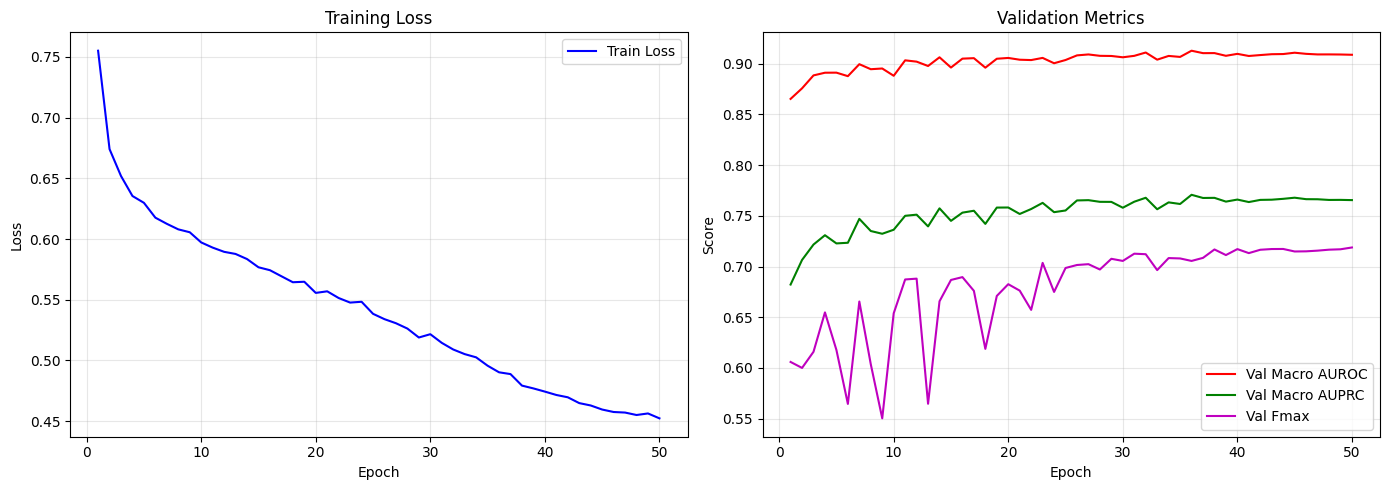

Results saved to /content/results_inception_baseline


In [15]:
# Cell 11: Save results & training curves
import matplotlib.pyplot as plt

# Save metrics CSV
with open(out_dir / 'metrics.csv', 'w', newline='') as f:
    w = csv.DictWriter(f, fieldnames=history[0].keys())
    w.writeheader()
    w.writerows(history)

# Save test metrics JSON
with open(out_dir / 'test_metrics.json', 'w') as f:
    json.dump({k: float(v) for k, v in test_metrics.items()}, f, indent=2)

# Plot training curves
epochs_arr = [h['epoch'] for h in history]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(epochs_arr, [h['train_loss'] for h in history], 'b-', label='Train Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(epochs_arr, [h['val_macro_auc'] for h in history], 'r-', label='Val Macro AUROC')
ax2.plot(epochs_arr, [h['val_macro_auprc'] for h in history], 'g-', label='Val Macro AUPRC')
ax2.plot(epochs_arr, [h['val_fmax'] for h in history], 'm-', label='Val Fmax')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Score')
ax2.set_title('Validation Metrics')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(out_dir / 'training_curves.png', dpi=150)
plt.show()
print(f'Results saved to {out_dir}')

In [16]:
# Cell 12: Copy results back to Drive
DRIVE_RESULTS = '/content/drive/MyDrive/ecg_results_inception_baseline/'
Path(DRIVE_RESULTS).mkdir(parents=True, exist_ok=True)

for f in out_dir.iterdir():
    shutil.copy2(f, DRIVE_RESULTS)
    print(f'Copied: {f.name}')

print(f'\nAll results saved to Google Drive: {DRIVE_RESULTS}')
print('Download best_model.pt and test_metrics.json to your local project.')

Copied: metrics.csv
Copied: best_model.pt
Copied: test_metrics.json
Copied: training_curves.png

All results saved to Google Drive: /content/drive/MyDrive/ecg_results_inception_baseline/
Download best_model.pt and test_metrics.json to your local project.


In [17]:
from sklearn.metrics import recall_score, precision_recall_curve

def detailed_test_report(y_true, y_pred, class_names):
    print('='*70)
    print(f'{"TEST — INCEPTIONTIME BASELINE":^70}')
    print('='*70)

    # 1. Core Metrics
    results = evaluate(y_true, y_pred, class_names)
    print(f'\n📊 Core Metrics')
    print(f'   Macro AUROC:  {results["macro_auc"]:.4f}')
    print(f'   Macro AUPRC:  {results["macro_auprc"]:.4f}')
    print(f'   Fmax:         {results["fmax"]:.4f} (optimal threshold: {results["optimal_threshold"]:.3f})')
    print(f'   F1 Macro:     {results["f1_macro"]:.4f} (@ threshold=0.50)')

    # 2. Per-Class Table
    print(f'\n📋 Per-Class Metrics')
    header = f'{"Class":<10} {"AUROC":<8} {"AUPRC":<8} {"F1":<8} {"Sens.":<8} {"Spec.":<8} {"Opt.Thr":<8} {"Support":<8}'
    print(header)
    print('-'*75)

    for i, name in enumerate(class_names):
        yt = y_true[:, i]
        yp = y_pred[:, i]

        # AUROC & AUPRC
        auc = roc_auc_score(yt, yp)
        precision, recall, thresholds = precision_recall_curve(yt, yp)
        auprc = average_precision_score(yt, yp)

        # Find Optimal Threshold for F1 per class
        f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)
        best_idx = np.argmax(f1_scores)
        opt_thr = thresholds[min(best_idx, len(thresholds)-1)]
        best_f1 = f1_scores[best_idx]

        # Sensitivity & Specificity at 0.5 threshold (standard)
        y_bin = (yp >= 0.5).astype(int)
        sens = recall_score(yt, y_bin, zero_division=0)
        spec = recall_score(1-yt, 1-y_bin, zero_division=0)

        support = int(yt.sum())

        print(f'{name:<10} {auc:<8.4f} {auprc:<8.4f} {best_f1:<8.4f} {sens:<8.4f} {spec:<8.4f} {opt_thr:<8.3f} {support:<8}')

    print('='*70)

# Execute with the variables from the previous cells
detailed_test_report(y_true_test, y_pred_test, class_names)

                    TEST — INCEPTIONTIME BASELINE                     

📊 Core Metrics
   Macro AUROC:  0.9067
   Macro AUPRC:  0.7643
   Fmax:         0.6964 (optimal threshold: 0.650)
   F1 Macro:     0.6789 (@ threshold=0.50)

📋 Per-Class Metrics
Class      AUROC    AUPRC    F1       Sens.    Spec.    Opt.Thr  Support 
---------------------------------------------------------------------------
NORM       0.9347   0.9003   0.8522   0.9180   0.8097   0.475    963     
MI         0.9167   0.8076   0.7333   0.7036   0.9193   0.415    550     
STTC       0.9237   0.7905   0.7403   0.8557   0.8446   0.651    506     
CD         0.9144   0.8238   0.7432   0.8165   0.8584   0.682    496     
HYP        0.8441   0.4995   0.4990   0.7939   0.6952   0.834    262     
